**Работу выполнил: Любошенко Артем**

# СберАвтоподписка -- аналитический отчёт

**Бизнес-цель:** повысить эффективность сайта долгосрочной аренды авто (рост конверсии, оценка каналов, оптимизация рекламы).

**ML-задача:** бинарная классификация на уровне визита (`session_id`) -- предсказать **вероятность целевого действия**. Главная метрика -- **ROC-AUC > 0.65**.

**Таргет:** 8 целевых действий (`sub_car_claim_click`, `sub_open_dialog_click`, `sub_submit_success`, ...). Базовый **CR ~ 2.705 %** (сильный дисбаланс).

> Анти-лик: модель использует ТОЛЬКО признаки уровня сессии (`utm_*`, `geo_*`, `device_*`, `visit_*`). Поля `ga_hits` -- только для построения таргета и EDA.

Отчёт исполняется сверху вниз (Restart & Run All): ячейки загружают артефакты, сгенерированные пайплайном (`data/`, `reports/`, `models/`).

In [24]:
import sys, json
from pathlib import Path
import pandas as pd, numpy as np
from IPython.display import display

ROOT = Path.cwd()
while not (ROOT / "src").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))
from src import config

def load_json(p): return json.loads(Path(p).read_text(encoding="utf-8"))
pd.set_option("display.max_columns", 60)
print("Корень проекта:", config.PROJECT_ROOT)

Корень проекта: /home/sovereign/Documents/НИЯУ_МИФИ/Practice_sem_2_git/MIPHI_internship_semester_2_SberAuto-subscription


## 1. Постановка задачи

Объект -- один визит (строка `ga_sessions`). Таргет `target=1`, если в `ga_hits` для визита есть >=1 целевое `event_action` (см. `config.TARGET_ACTIONS`). Оценка -- ROC-AUC + PR-AUC (из-за дисбаланса). Выход сервиса -- `0/1` + вероятность.

In [25]:
print("Целевые действия (8):")
for a in sorted(config.TARGET_ACTIONS): print(" -", a)

Целевые действия (8):
 - sub_call_number_click
 - sub_callback_submit_click
 - sub_car_claim_click
 - sub_car_claim_submit_click
 - sub_car_request_submit_click
 - sub_custom_question_submit_click
 - sub_open_dialog_click
 - sub_submit_success


## 2. Чтение данных и очистка

Сырьё: `ga_sessions.csv` (1 860 042 x 18) и `ga_hits.csv` (4 ГБ, только для таргета). Конвертация в parquet + category; таргет построен потоковым сканом hits.

In [26]:
ing = load_json(config.INGESTION_STATS_JSON)
cln = load_json(config.CLEANING_STATS_JSON)
print(f"Сессий: {ing['n_sessions']:,} x {ing['n_columns']} кол.; session_id уникален: {ing['session_id_unique']}")
print(f"CR: {ing['conversion_rate']*100:.3f}%  ({ing['n_target_sessions']:,} целевых сессий)")
print(f"Сессий без событий в hits: {ing['pct_sessions_without_hits']:.2f}%")
print(f"Диапазон visit_date: {ing['visit_date_min']} ... {ing['visit_date_max']}")

Сессий: 1,860,042 x 18 кол.; session_id уникален: True
CR: 2.705%  (50,314 целевых сессий)
Сессий без событий в hits: 6.87%
Диапазон visit_date: 2021-05-19 ... 2021-12-31


In [27]:
# Таблица доли пропусков ДО и ПОСЛЕ очистки
nan_tbl = pd.DataFrame({"NaN_до_%": pd.Series(cln["nan_before"]),
                        "NaN_после_%": pd.Series(cln["nan_after"])}).sort_values("NaN_до_%", ascending=False)
nan_tbl

,NaN_до_%,NaN_после_%
device_model,99.1216,NaN
utm_keyword,58.1740,0.0
device_os,57.5330,0.0
device_brand,19.7403,0.0
utm_adcontent,18.0434,0.0
utm_campaign,11.8063,0.0
utm_source,0.0052,0.0
device_browser,0.0000,0.0
client_id,0.0000,0.0
device_category,0.0000,0.0


In [28]:
df = pd.read_parquet(config.DATASET_PARQUET)
print("processed/dataset.parquet:", df.shape, "| дубликатов строк удалено:", cln["full_row_duplicates_dropped"])
display(df.head(3))
df.dtypes.to_frame("dtype")

processed/dataset.parquet: (1860042, 18) | дубликатов строк удалено: 0


,session_id,client_id,visit_date,visit_time,visit_number,utm_source,utm_medium,utm_campaign,utm_adcontent,utm_keyword,device_category,device_os,device_brand,device_screen_resolution,device_browser,geo_country,geo_city,target
0,9055434745589932991.1637753792.1637753792,2108382700.1637753791,2021-11-24,52592,1,ZpYIoDJMcFzVoPFsHGJL,banner,LEoPHuyFvzoNfnzGgfcd,vCIpmpaGBnIQhyYNkXqp,puhZPIYqKXeFPaUviSjo,mobile,Android,Huawei,360x720,Chrome,Russia,Zlatoust,0
1,905544597018549464.1636867290.1636867290,210838531.1636867288,2021-11-14,30090,1,MvfHsxITijuriZxsqZqt,cpm,FTjNLDyTrXaWYgZymFkV,xhoenQgDQsgfEPYNPwKO,IGUCNvHlhfHpROGclCit,mobile,Android,Samsung,385x854,Samsung Internet,Russia,Moscow,0
2,9055446045651783499.1640648526.1640648526,2108385331.1640648523,2021-12-28,9726,1,ZpYIoDJMcFzVoPFsHGJL,banner,LEoPHuyFvzoNfnzGgfcd,vCIpmpaGBnIQhyYNkXqp,puhZPIYqKXeFPaUviSjo,mobile,Android,Huawei,360x720,Chrome,Russia,Krasnoyarsk,0


,dtype
session_id,string
client_id,string
visit_date,datetime64[us]
visit_time,Int64
visit_number,int32
utm_source,category
utm_medium,category
utm_campaign,category
utm_adcontent,category
utm_keyword,category


**Выводы по очистке.** `device_model` удалён (99.12 % NaN -- нет сигнала; виден в таблице как "NaN_после" = NaN). Пропуски категорий заменены на информативную `unknown` (строки не выбрасываются). Типы приведены: `visit_date`->datetime, `visit_time`->секунды, остальные строковые->category. Значение `utm_medium == '(none)'` сохранено как органика. Полных дубликатов строк нет, `target` без NaN.

## 3. Разведочный анализ (EDA) и статистические гипотезы

In [29]:
eda = load_json(config.EDA_STATS_JSON)
b = eda["business"]
print(f"Общий CR: {eda['overall_cr']*100:.3f}%  (сильный дисбаланс)")
pd.DataFrame({
 "сегмент": ["органика","платный","соцсети","прочие источники","новые визиты","возвратные визиты"],
 "CR, %": [round(b['cr_organic']*100,3), round(b['cr_paid']*100,3), round(b['cr_social']*100,3),
           round(b['cr_other']*100,3), round(b['cr_new']*100,3), round(b['cr_returning']*100,3)],
})

Общий CR: 2.705%  (сильный дисбаланс)


,сегмент,"CR, %"
0,органика,4.036
1,платный,2.194
2,соцсети,1.466
3,прочие источники,2.919
4,новые визиты,2.352
5,возвратные визиты,3.711


**Баланс классов и ключевые CR-разрезы**

**reports/figures/class_balance.png**

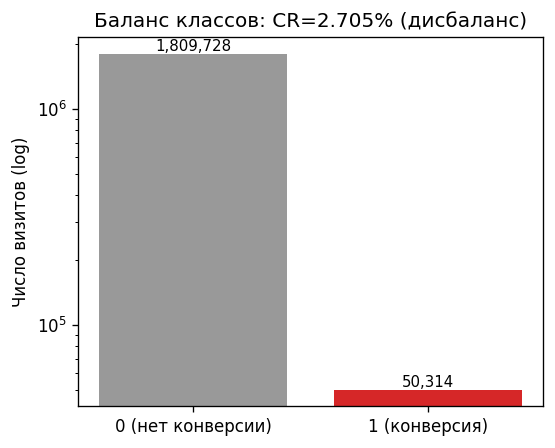

**reports/figures/cr_organic_vs_paid.png**

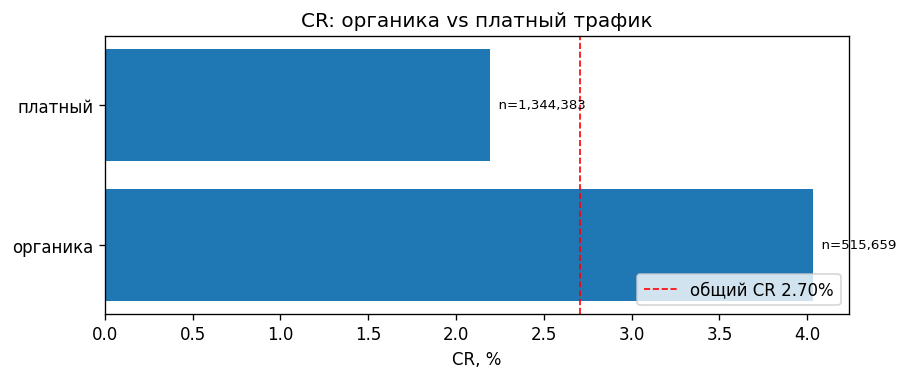

**reports/figures/cr_by_device_category.png**

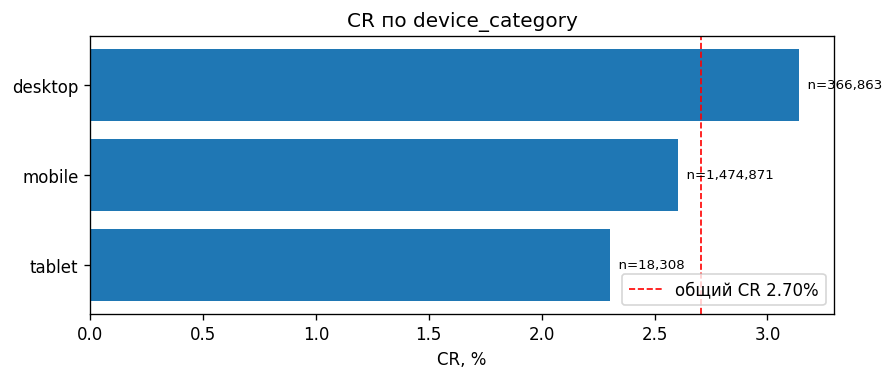

**reports/figures/cr_new_vs_returning.png**

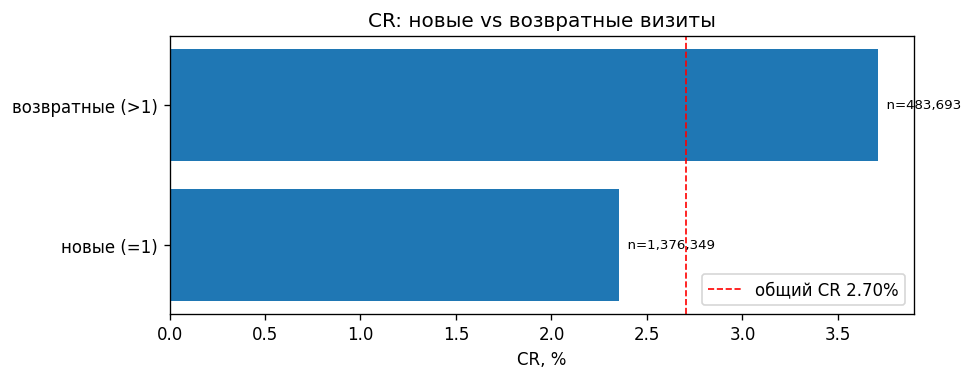

**reports/figures/cr_social_vs_other.png**

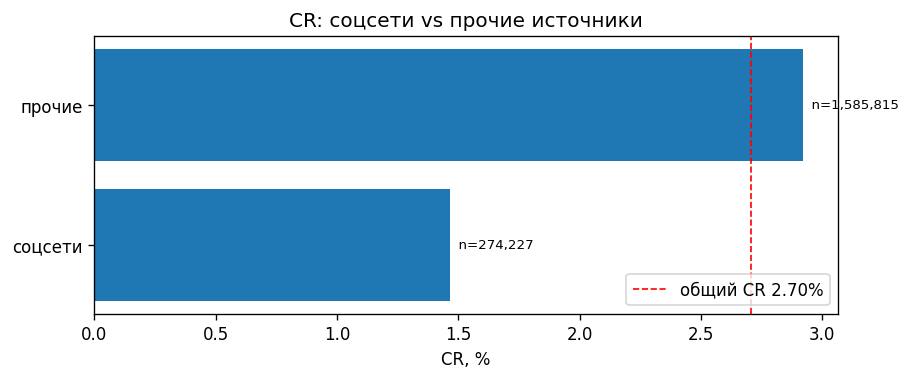

**reports/figures/cr_by_hour.png**

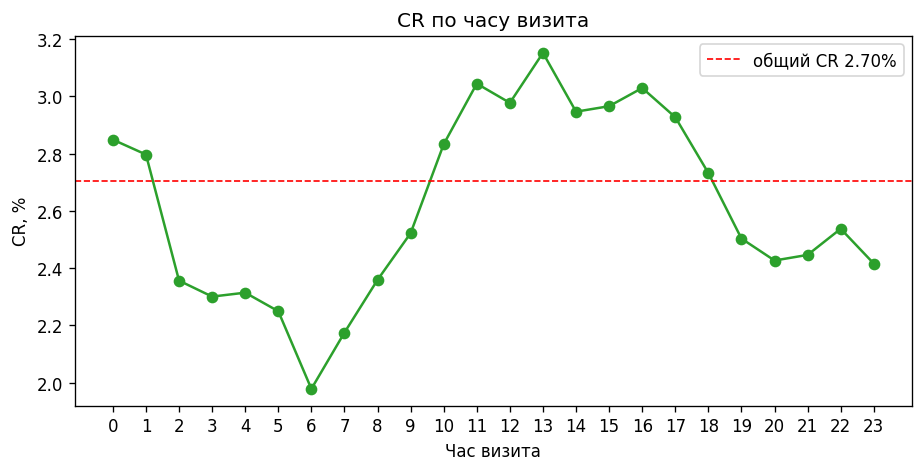

**reports/figures/cr_by_utm_medium.png**

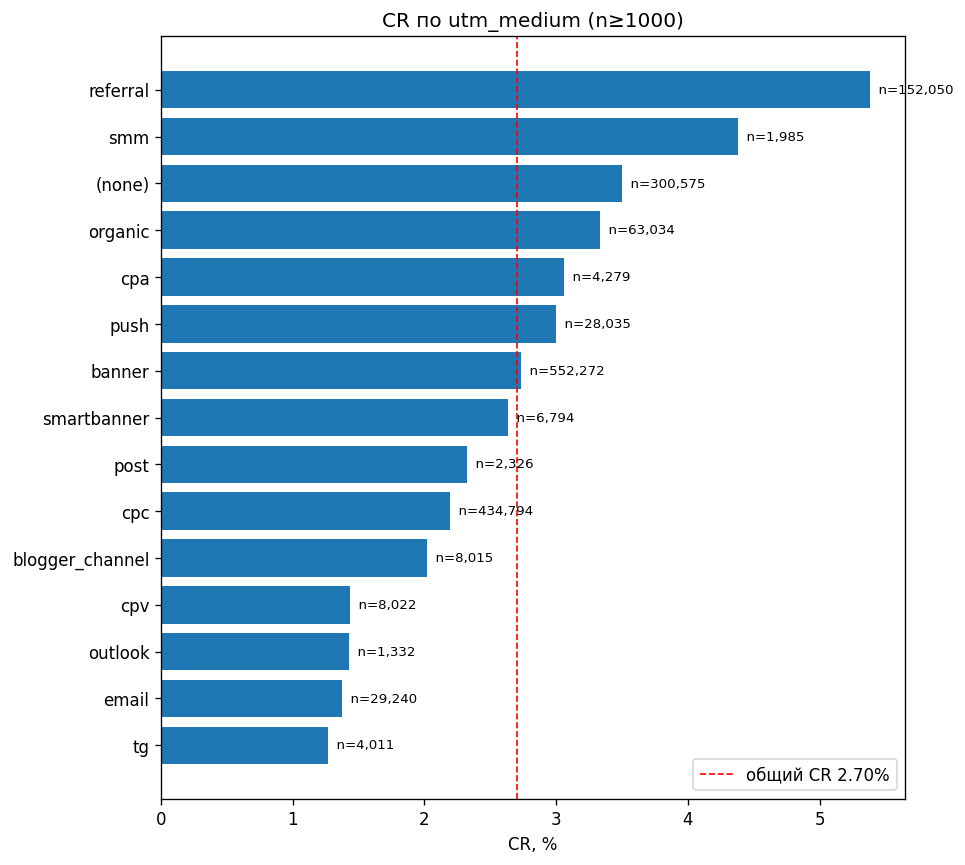


**Интерпретация разрезов.** Конверсия органики (~4.0 %) заметно выше платного трафика (~2.2 %). По устройствам: desktop > mobile > tablet. Возвратные визиты конвертируют лучше новых (~3.7 % vs ~2.4 %). Соцсети -- ниже прочих источников. Есть выраженный суточный паттерн CR по часам. Это формирует гипотезы полезных признаков (тип трафика, новизна визита, устройство, время).

**Корреляции категориальных признаков (Cramér's V)**

**reports/figures/cramers_v_heatmap.png**

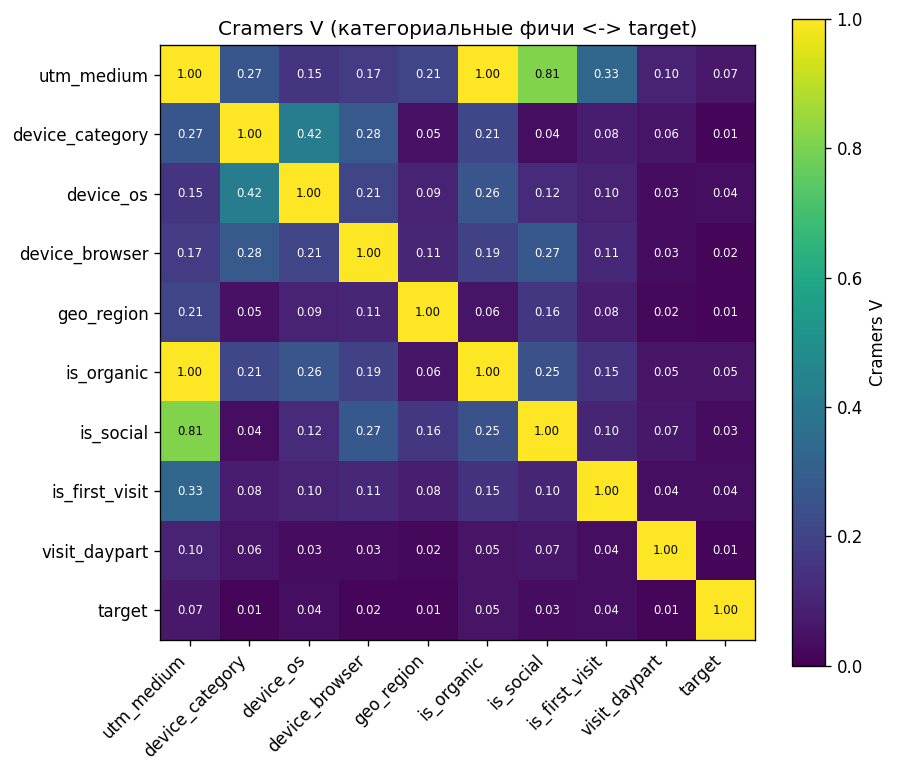


In [30]:
# Формально проверенные гипотезы (alpha=0.05, поправка Бонферрони)
hyp = pd.DataFrame([{"id":h["id"], "гипотеза":h["name"], "тест":h["test"],
                     "статистика":round(h["statistic"],2), "p_value":h["pvalue"],
                     "H0 отвергнута":h["reject_h0"]} for h in eda["hypotheses"]])
hyp

,id,гипотеза,тест,статистика,p_value,H0 отвергнута
0,H1,Органика vs платный трафик <-> конверсия,z-тест долей,69.30,0.000000e+00,True
1,H2,Тип устройства <-> конверсия,χ^2 независимости,331.99,8.131635e-73,True
2,H3,Новые vs возвратные визиты <-> конверсия,z-тест долей,-50.12,0.000000e+00,True
3,H4,Соцсети vs прочие источники <-> конверсия,z-тест долей,-43.30,0.000000e+00,True


**Гипотезы (>=3, все отвергают H0 при alpha=0.05 с поправкой Бонферрони).**
1. **Органика vs платный** -- CR различаются (z-тест долей, p~0). Органика конвертирует выше.
2. **Тип устройства** -- CR зависит от `device_category` (chi^2, p~10^(-73)).
3. **Новые vs возвратные** -- CR различаются (z-тест, p~0); возвратные выше.
4. **Соцсети vs прочие** -- CR различаются (z-тест, p~0); соцсети ниже.

Связи слабые по Cramers V (V<=0.07) -- задача объективно "трудная", что согласуется с реалистичным порогом ROC-AUC 0.65.

## 4. Подход к ML

Признаки -- только session-уровень, собраны в единый sklearn `Pipeline` (`SessionFeatureBuilder -> RareCategoryGrouper -> OHE/native cat`). Мультиколлинеарность проверена (VIF).

In [31]:
vif = load_json(config.VIF_JSON)
print("Числовых признаков:", len(vif["vif"]), "| VIF>10 после устранения коллинеарности:", vif["flagged"] or "нет")
print("Исключены по построению/VIF:", ", ".join(d["name"] for d in vif["dropped_by_design"]))
fi = load_json(config.FEATURE_IMPORTANCE_JSON)
pd.Series(fi["mi_by_original_feature"]).head(12).to_frame("MI (агрегировано)")

Числовых признаков: 16 | VIF>10 после устранения коллинеарности: нет
Исключены по построению/VIF: is_paid, is_mobile, screen_area, screen_aspect, geo_country, device_model


,MI (агрегировано)
utm_adcontent,0.030907
utm_keyword,0.030593
device_browser,0.029676
device_os,0.028424
device_category,0.027506
visit_daypart,0.022700
geo_city,0.021014
utm_source,0.020682
utm_medium,0.018008
utm_campaign,0.017690


In [32]:
# Сравнение моделей (honest hold-out) и критерий приёмки
metrics = load_json(config.METRICS_JSON); meta = load_json(config.METADATA_JSON)
comp = pd.DataFrame({k: {"ROC_AUC": v["roc_auc"], "PR_AUC": v["pr_auc"]}
                     for k, v in metrics["comparison"].items()}).T
print("Разбиение:", meta["validation_split"], "| THRESHOLD:", meta["THRESHOLD"])
print("Acceptance ROC-AUC>0.65:", metrics["acceptance"]["passed"])
comp

Разбиение: stratified_random | THRESHOLD: 0.67806
Acceptance ROC-AUC>0.65: True


,ROC_AUC,PR_AUC
dummy_prior,0.50000,0.02705
logreg_base,0.61208,0.03900
logreg_full,0.68752,0.05822
random_forest,0.70016,0.06327
catboost,0.71262,0.07174
catboost_final,0.71306,0.07216


**Кривые, калибровка, важности признаков, SHAP**

**reports/figures/roc_pr_curves.png**

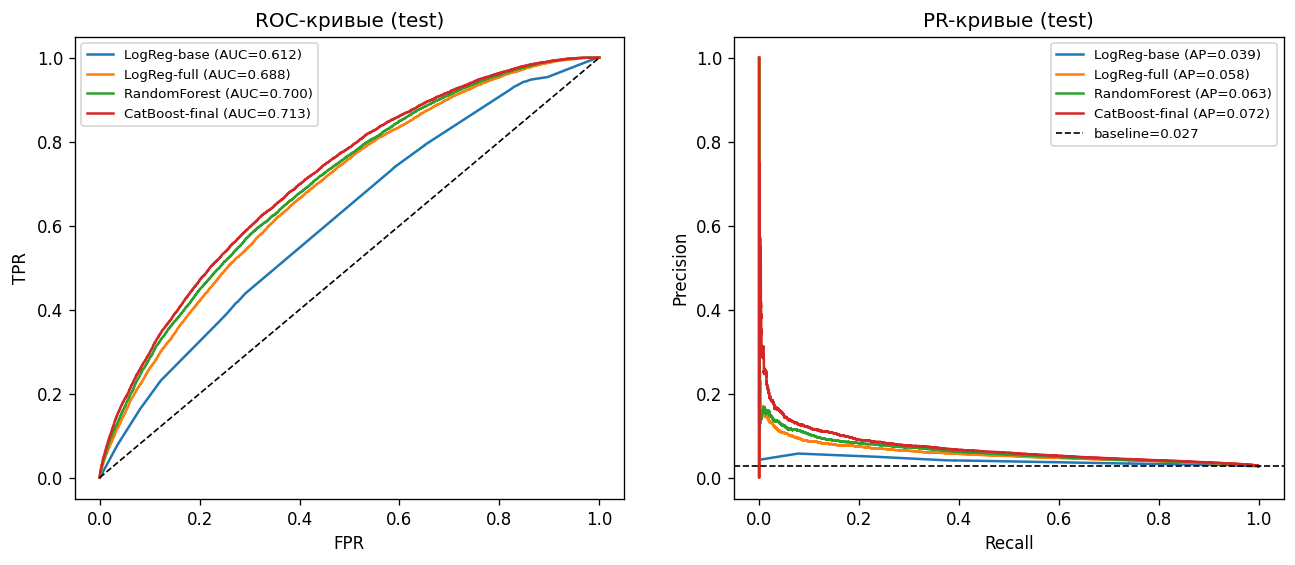

**reports/figures/confusion_matrix.png**

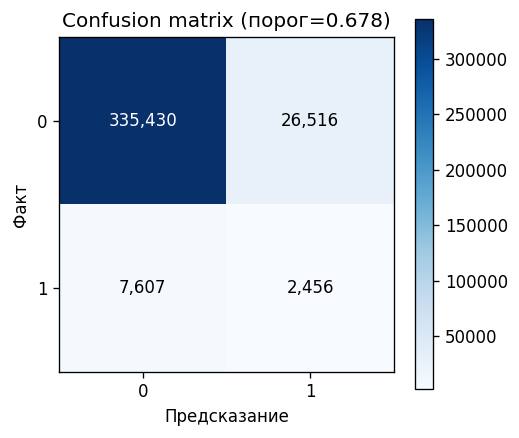

**reports/figures/calibration_curve.png**

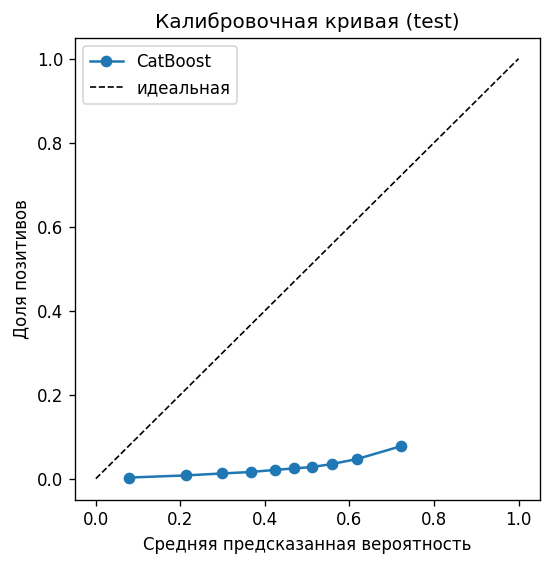

**reports/figures/catboost_feature_importance.png**

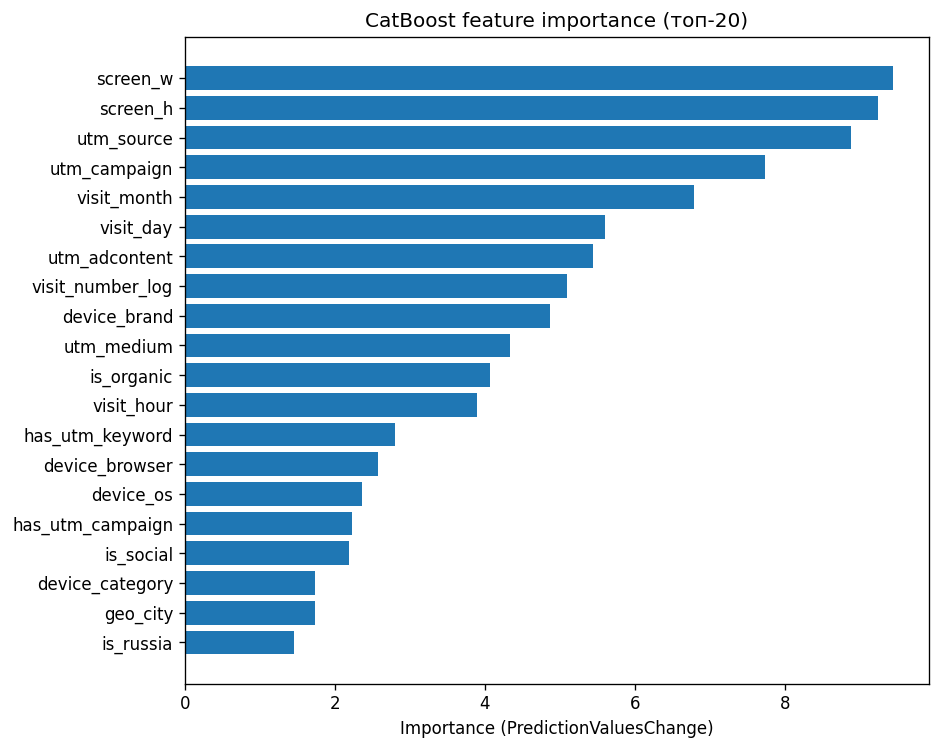

**reports/figures/shap_summary.png**

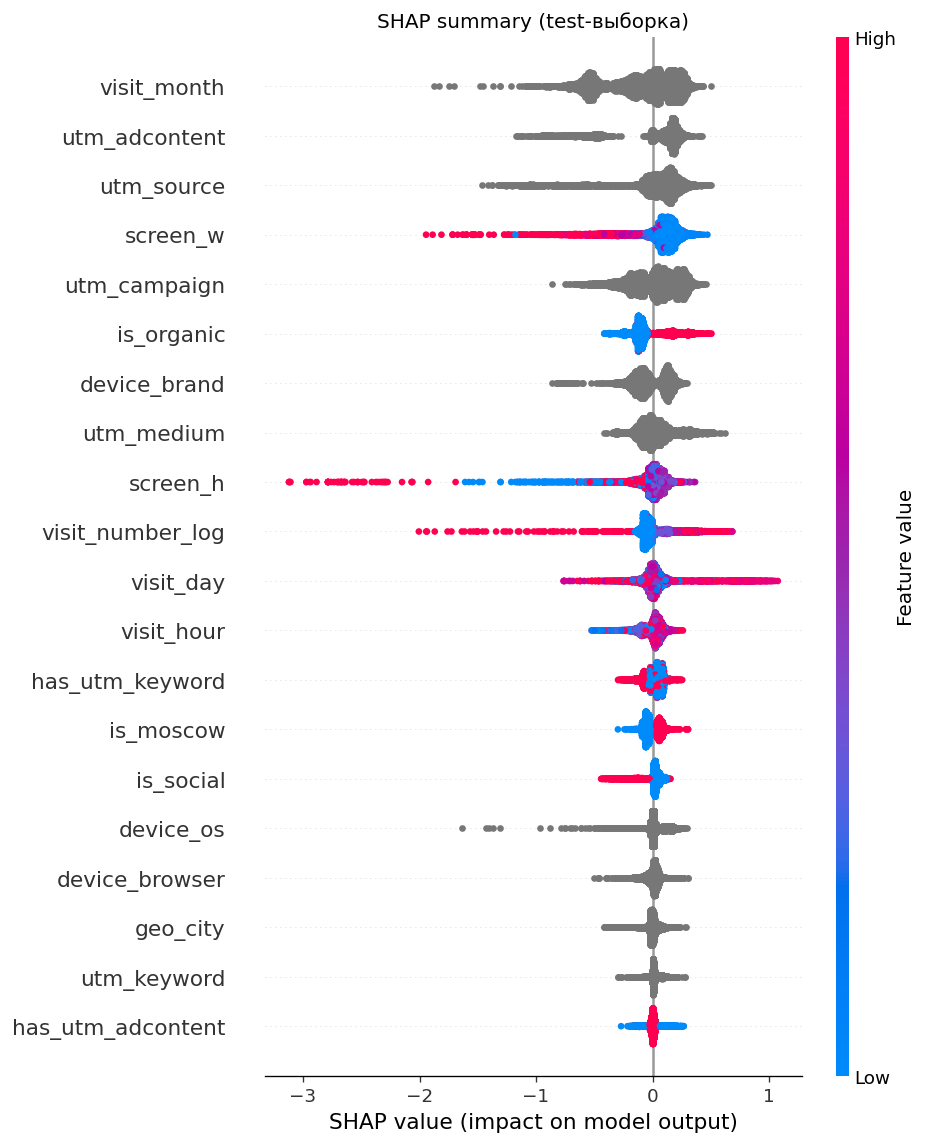


**Результаты ML.** Сравнение: Dummy 0.50 -> LogReg-base 0.61 -> LogReg-full 0.69 -> RandomForest 0.70 -> **CatBoost 0.713** (лучшая, > 0.65 и существенно выше бейзлайна). Дисбаланс учтён (`auto_class_weights='Balanced'`, PR-AUC, подбор порога F1). Важности (CatBoost + SHAP + permutation) подтверждают гипотезы EDA: ведущие факторы -- тип трафика, рекламные идентификаторы (`utm_adcontent/campaign/source`), время визита, устройство, гео.

In [33]:
# Демонстрация инференса через тот же pipeline.joblib, что в API
from api import model as model_api
pipeline, model_meta = model_api.load_artifacts()
sample_visit = {"utm_source":"ZpYIoDJMcFzVoPFsHGJL","utm_medium":"organic","device_category":"desktop",
                "device_browser":"Chrome","device_screen_resolution":"1920x1080","geo_city":"Moscow",
                "visit_number":3,"visit_date":"2021-09-10","visit_time":"19:45:00"}
model_api.predict(pipeline, model_meta, [sample_visit])

[{'prediction': 0,
  'probability': 0.548135,
  'model_version': '2026-05-31T15:04:35+00:00'}]

## 5. Выводы

- **Достигнут порог:** лучшая модель **CatBoost, ROC-AUC = 0.713 > 0.65** на отложенной выборке, заметно выше бейзлайнов (Dummy 0.50, LogReg 0.69).
- **Бизнес-инсайты:** органический трафик и возвратные визиты конвертируют выше; соцсети -- ниже; desktop > mobile > tablet; важны рекламные идентификаторы и время визита. Это даёт ориентиры для оптимизации каналов и таргетинга.
- **Ограничения:** низкий precision/PR-AUC из-за дисбаланса (CR 2.7 %) -- модель пригодна для ранжирования лидов; порог 0/1 настраивается под бизнес-cost. Признаки кампаний дрейфуют во времени -> нужна периодическая переобучка (на разбиении по времени AUC падает до ~0.63 -- задокументировано).
- **Воспроизводимость и сервис:** единый `pipeline.joblib` (train=serve), FastAPI (p95 ~ 70 мс) + Streamlit, юнит-тесты (47 passed), фиксированные версии (`requirements.txt`).
- **Улучшения:** калибровка вероятностей, target-encoding высоко-кардинальных признаков с OOF, мониторинг дрейфа и регулярная переобучка.